<h1><b>Test modelo Yolov8-OBB

<p>Este notebook busca realizar una prueba de entrenamiento por transfer learning, de un modelo detector de lomos de libros. Para ello, se utiliza la arquitectura de YOLOv8-OBB (oriente bounding boxes).<br>Este modelo se elige a partir del EDA realizado, en el cuál se detectó que muchas de las imagenes poseen los libros inclinados, y un bounding-box "standar" abarcaría mucho espacio no correspondiente al objeto deseado</p> 

<h2>Importación de librerias

In [2]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import transforms
import matplotlib.pyplot as plt
import os
import random

Verificación de disponibilidad de GPU

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


<h2>Descarga dataset para YOLO26

In [4]:
from roboflow import Roboflow

In [ ]:
ruta_dataset = r'./Book_spie_2-4'

# Verificamos si el archivo de configuración de YOLO ya existe en esa ruta
if (ruta_dataset / "data.yaml").exists():
    print(f"El dataset ya se encuentra en '{ruta_dataset}'. Omitiendo descarga.")
else:
    rf = Roboflow(api_key=os.environ.get("ROBOFLOW_API_KEY", "").strip())
    project = rf.workspace("bookspine-fxfsx").project("book_spine_2")
    version = project.version(4)
    dataset = version.download("yolov8-obb",location=r'ruta_dataset')
                

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Book_spine_2-4 in yolov8-obb:: 100%|██████████| 3324/3324 [00:05<00:00, 592.23it/s]


<h2>Entrenamiento del modelo

In [4]:
from ultralytics import YOLO

#a diferencia de AlexNet, en YOLO no debemos modificar su arquitectura. La indicación de clases de salida, se da en el data.yaml

#instanciamos el modelo
yolo_obb_ft = YOLO("yolov8s-obb.pt")
yolo_obb_ft = yolo_obb_ft.to(device)


# Entrenamiento del modelo
results = yolo_obb_ft.train(
    data=r'../Book_Spine_2-4/data.yaml',     #path al yaml del dataset
    epochs=25,                              #numero total de épocas de entrenamiento
    #time
    #patience = 12                             #Número de épocas sin mejora que espera antes de cortar el entrenamiento
    batch=32,                                #Cantidad de elementos del batch (si entero, se usa ese número | -1: automático, utilización 60% de memoria del GPU | fraccion: especifica % de uso de memoria de GPU)
    imgsz=640,
    save=True,                                  #1: guarda los pesos obtenidos
    #save_period
    #cache
    device=device,
    pretrained=True,                         #False: mantiene solo la arquitectura | True: usa pesos pre-entrenados
    optimizer='SGD',                         #opciones: SGD, MuSGD, Adam, Adamax, AdamW, NAdam, RAdam, RMSProp, or auto to pick AdamW or MuSG    
    seed=0,                                  #semilla para reproducibilidad de resultados (default 0)
    #deterministic
    verbose=True,                            #Habilita verbosidad durante entrenamiento
    single_cls=True,                          #Para casos en los que hay una sola clase o para tareas donde premia la detección de presencia por sobre la clasificación
    #classes                                #Specifies a list of class IDs to train on. Useful for filtering out and focusing only on certain classes during training.
    lr0=1e-3,                                    #learning rate inicial
    lrf=1e-3,                                    #learning rate final
    momentum=0,                              #momentum para SGD o beta1 para Adam
    weight_decay=0.0005,                     #regularización L2
    )

New https://pypi.org/project/ultralytics/8.4.155 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.150  Python-3.13.2 torch-2.14.0+cu126 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../Book_Spine_2-4/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.001, mask_ratio=4, max_det=300, mixup=0.0, mod

<h2>Prueba con YOLO26-OBB

In [6]:
from ultralytics import YOLO

#instanciamos el modelo
yolo_obb_ft = YOLO("yolo26s-obb.pt")
yolo_obb_ft = yolo_obb_ft.to(device)


# Entrenamiento del modelo
results = yolo_obb_ft.train(
    data=r'../Book_Spine_2-4/data.yaml',     #path al yaml del dataset
    epochs=25,                              #numero total de épocas de entrenamiento
    #time
    #patience = 12                             #Número de épocas sin mejora que espera antes de cortar el entrenamiento
    batch=32,                                #Cantidad de elementos del batch (si entero, se usa ese número | -1: automático, utilización 60% de memoria del GPU | fraccion: especifica % de uso de memoria de GPU)
    imgsz=640,
    save=True,                                  #1: guarda los pesos obtenidos
    #save_period
    #cache
    device=device,
    pretrained=True,                         #False: mantiene solo la arquitectura | True: usa pesos pre-entrenados
    optimizer='SGD',                         #opciones: SGD, MuSGD, Adam, Adamax, AdamW, NAdam, RAdam, RMSProp, or auto to pick AdamW or MuSG    
    seed=0,                                  #semilla para reproducibilidad de resultados (default 0)
    #deterministic
    verbose=True,                            #Habilita verbosidad durante entrenamiento
    single_cls=True,                          #Para casos en los que hay una sola clase o para tareas donde premia la detección de presencia por sobre la clasificación
    #classes                                #Specifies a list of class IDs to train on. Useful for filtering out and focusing only on certain classes during training.
    lr0=1e-3,                                    #learning rate inicial
    lrf=1e-3,                                    #learning rate final
    momentum=0,                              #momentum para SGD o beta1 para Adam
    weight_decay=0.0005,                     #regularización L2
    )

New https://pypi.org/project/ultralytics/8.4.155 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.150  Python-3.13.2 torch-2.14.0+cu126 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../Book_Spine_2-4/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.001, mask_ratio=4, max_det=300, mixup=0.0, mod

<h2>Prueba de enmascaramiento

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

In [27]:
#Plotea imagen usando matplotlib
def plot_image(img,title):

    plt.title(title) 
    plt.xlabel("x axis") 
    plt.ylabel("y axis") 
    plt.imshow(cv.cvtColor(img,cv.COLOR_BGR2RGB))
    plt.show()

In [56]:
#instancio el modelo entrenado con YOLO26, usando los mejores pesoss obtenidos
model = YOLO(r'../runs/obb/train-7 - YOLO26/weights/best.pt')


#Hago una predicción en una imagen
img_path = r'../Book_spine_2-4/test/images/0_045_jpg.rf.a41b0608eda9fc4f12ae22f3bb11e958.jpg'
img = cv.imread(img_path)

resultados = model.predict(img, conf=0.5,iou=0.7)
resultado = resultados[0]



0: 640x640 8 items, 72.6ms
Speed: 4.6ms preprocess, 72.6ms inference, 10.4ms postprocess per image at shape (1, 3, 640, 640)


C:\Users\IanEz\AppData\Local\Temp\ipykernel_17536\1103438691.py:9: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  pts = np.array(coord,dtype=np.int32)


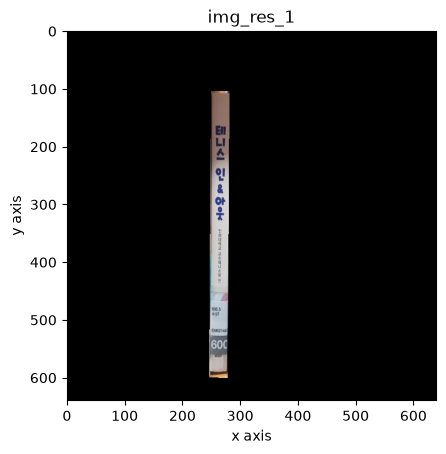

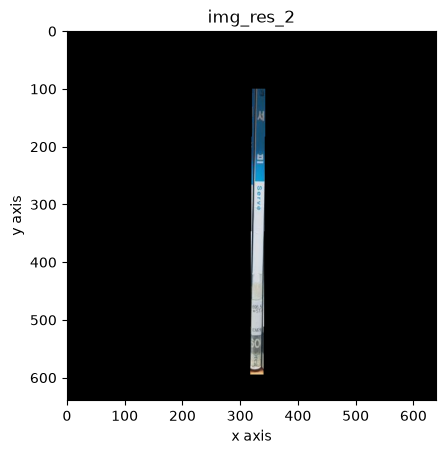

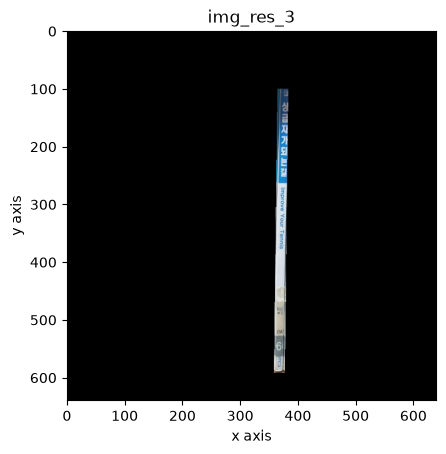

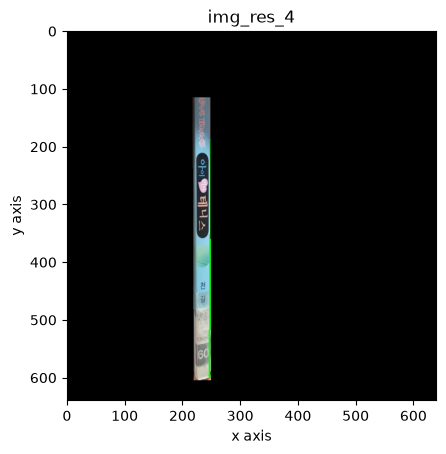

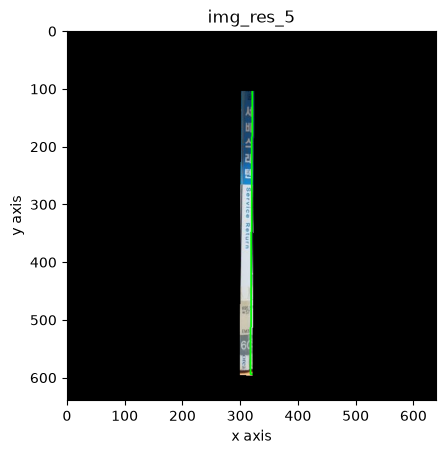

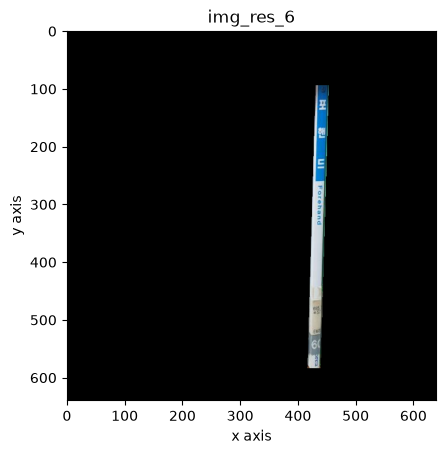

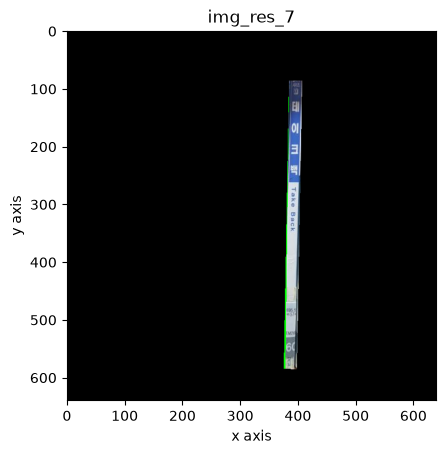

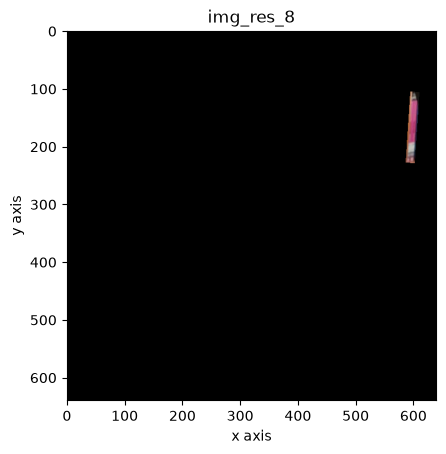

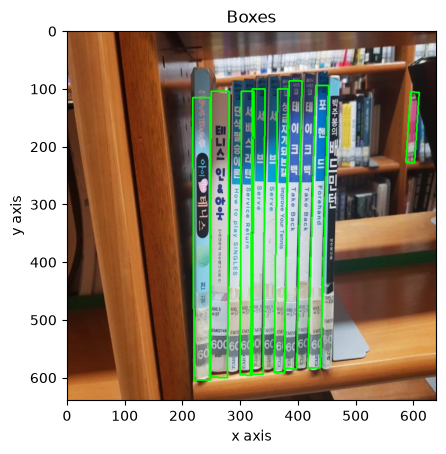

In [57]:
#hay que pasar el resultado a cpu para utilizar numpy
resultado = resultado.to('cpu')       
img_nbr = 1

#resultado.obb.xyxyxyxy: posee las coordenadas de los 4 puntos de la bounding box detectada para cada objeto
for coord in resultado.obb.xyxyxyxy:

    #para fillPoly, tenemos que convertir a un np.array y formato entero
    pts = np.array(coord,dtype=np.int32)
    #OpenCV requiere que pts posea un tercera dimensión
    pts = pts.reshape((-1, 1, 2)) 

    #definimos máscara
    mask = np.zeros(shape=(img.shape[0],img.shape[1]),dtype=np.uint8)
    cv.fillPoly(mask,[pts],color=(255,255,255))


    #aplicamos la máscara
    img_res = cv.bitwise_and(img,img,mask=mask)

    #dibujo el boundig box
    img_boxes = cv.polylines(img,[pts],color=(0,255,0),isClosed=True,thickness=2)

    #imprimimos imagen
    plot_image(img_res,f'img_res_{img_nbr}')
    img_nbr+=1

plot_image(img_boxes,'Boxes')


<p>Con conf 0.32: En la prueba realizada, vemos que de los libros que están en primer plano, se omitieron dos. Uno se encontró de un tamaño menor al real. Además, hay bounding-boxes solapadas.<br>Además, se detectaron libros que están al fodo, que resultan demasiado pequeños para OCR </p><p>Con conf 0.5: En la prueba realizada, vemos que de los libros que están en primer plano, se omitieron tres( el que antes se encontraba de un tamaño menor al real, fue descartado). No hay bounding-boxes solapadas.<br>Se detectaron menos del fondo</p>  